In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import mlflow
import pandas as pd
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

from chesswinnerprediction.baseline.double_stage_wrapper import Model
from chesswinnerprediction.baseline.custom_knn import CustomKNNClassifier
from chesswinnerprediction.baseline.utils import (
    get_x_and_y,
    transform_and_scale_df,
)
from chesswinnerprediction.baseline.constants import BASELINE_RANDOM_STATE
from chesswinnerprediction.constants import DRAW_STR, PROCESSED_FOLDER_PATH, WHITE_WIN_STR, BLACK_WIN_STR
from config import BASELINE_EXPERIMENT, MLRUNS_FOLDER_PATH

## MLFlow Configuration

In [3]:
mlflow.set_tracking_uri(MLRUNS_FOLDER_PATH)

In [4]:
if mlflow.get_experiment_by_name(BASELINE_EXPERIMENT) is not None:
    experiment_id = mlflow.get_experiment_by_name(BASELINE_EXPERIMENT).experiment_id
else:
    experiment_id = mlflow.create_experiment(BASELINE_EXPERIMENT)

In [5]:
mlflow.set_experiment(experiment_id=experiment_id)
mlflow.sklearn.autolog(disable=True)

In [6]:
double_stage_run = mlflow.start_run(run_name="double stage model optimization")
double_stage_run_id = double_stage_run.info.run_id
mlflow.end_run()

## Data Preparation

In [7]:
data_dir = "lichess_db_standard_rated_2017-05"
data_path = os.path.join(PROCESSED_FOLDER_PATH, data_dir)

In [8]:
train_df = pd.read_csv(os.path.join(data_path, "train.csv"))
valid_df = pd.read_csv(os.path.join(data_path, "valid.csv"))
test_df = pd.read_csv(os.path.join(data_path, "test.csv"))

In [9]:
train_sample_size = 0.2
valid_sample_size = 0.1
test_sample_size = 1

In [10]:
train_df = train_df.sample(frac=train_sample_size, random_state=BASELINE_RANDOM_STATE)
valid_df = valid_df.sample(frac=valid_sample_size, random_state=BASELINE_RANDOM_STATE)
test_df = test_df.sample(frac=test_sample_size, random_state=BASELINE_RANDOM_STATE)

In [11]:
print(f"Train shape: {train_df.shape}")
print(f"Valid shape: {valid_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (158137, 20)
Valid shape: (9526, 20)
Test shape: (66685, 20)


In [12]:
std_scaler = StandardScaler()
train_data = transform_and_scale_df(train_df, std_scaler)
valid_data = transform_and_scale_df(valid_df, std_scaler, fit_scaler=False)
test_data = transform_and_scale_df(test_df, std_scaler, fit_scaler=False)

In [13]:
X_train, y_train = get_x_and_y(train_data, predict_draws=True)
X_valid, y_valid = get_x_and_y(valid_data, predict_draws=True)
X_test, y_test = get_x_and_y(test_data, predict_draws=True)

### Optuna Optimization

In [14]:
def balance_dataset(x, y, class_weight, random_state):
    data_df = pd.concat([x, y], axis=1)    
    base = y.value_counts().min() 
    
    balanced_df = pd.concat([
        resample(
            data_df[y == target],
            replace=(base * weight) > y.value_counts()[target],
            n_samples=int(base * weight),
            random_state=random_state
        )
        for target, weight in class_weight.items()
    ])
    
    return balanced_df[x.columns], balanced_df[y.name]

In [15]:
model_suggestion_list = ["decision_tree", "random_forest", "gradient_boosting", "logistic_regression", "custom_knn"]
models = [DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, LogisticRegression, CustomKNNClassifier]

models_dict = dict(zip(model_suggestion_list, models))

In [16]:
def get_splitter_model(trial: optuna.Trial, model_type, splitter_type):
    if model_type == "decision_tree":
        prefix = f"{splitter_type}-{model_type}-"
        model = DecisionTreeClassifier(
            random_state=BASELINE_RANDOM_STATE,
            class_weight="balanced",
            max_depth=trial.suggest_int(f"{prefix}max_depth", 2, 32),
            min_samples_leaf=trial.suggest_int(f"{prefix}min_samples_leaf", 1, X_train.shape[0]),
            max_features=trial.suggest_categorical(f"{prefix}max_features", [None, "sqrt", "log2"]),
        )
    elif model_type == "random_forest":
        prefix = f"{splitter_type}-{model_type}-"
        model = RandomForestClassifier(
            random_state=BASELINE_RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
            n_estimators=trial.suggest_int(f"{prefix}n_estimators", 10, 800),
            max_depth=trial.suggest_int(f"{prefix}max_depth", 2, 20),
            min_samples_leaf=trial.suggest_int(f"{prefix}min_samples_leaf", 1, X_train.shape[0]),
            max_features=trial.suggest_categorical(f"{prefix}max_features", [None, "sqrt", "log2"]),
        )
    elif model_type == "gradient_boosting":
        prefix = f"{splitter_type}-{model_type}-"
        model = GradientBoostingClassifier(
            random_state=BASELINE_RANDOM_STATE,
            n_estimators=trial.suggest_int(f"{prefix}n_estimators", 2, 300),
            max_depth=trial.suggest_int(f"{prefix}max_depth", 2, 16),
            min_samples_leaf=trial.suggest_int(f"{prefix}min_samples_leaf", 1, X_train.shape[0]),
            max_features=trial.suggest_categorical(f"{prefix}max_features", [None, "sqrt", "log2"]),
        )
    elif model_type == "logistic_regression":
        prefix = f"{splitter_type}-{model_type}-"
        model = LogisticRegression(
            random_state=BASELINE_RANDOM_STATE,
            class_weight="balanced",
            solver="liblinear",
            penalty="l2",
            max_iter=trial.suggest_int(f"{prefix}max_iter", 2, 100),
            C=trial.suggest_float(f"{prefix}C", 0.01, 10),
            tol=trial.suggest_float(f"{prefix}tol", 0.001, 1)
        )
    elif model_type == "custom_knn":
        prefix = f"{splitter_type}-{model_type}-"
        
        if splitter_type == "win_to_draw":
            class_weights = {
                Model.win_to_draw_splitter_win_symbol: trial.suggest_float(f"{prefix}win_constant", 1, 2),
                Model.win_to_draw_splitter_draw_symbol: trial.suggest_float(f"{prefix}draw_constant", 1, 3),
            }
        else:
            black_white_win_constant = trial.suggest_float(f"{prefix}black_white_win_constant", 1, 2)
            class_weights = {
                WHITE_WIN_STR: black_white_win_constant,
                BLACK_WIN_STR: black_white_win_constant,
            }
        model = CustomKNNClassifier(
            random_state=BASELINE_RANDOM_STATE,
            class_weight=class_weights,
            balance_dataset_func=balance_dataset,
            score_size=0.25,
            n_jobs=-1,
            weights=trial.suggest_categorical(f"{prefix}weights", ["uniform", "distance"]),
            n_neighbors=trial.suggest_int(f"{prefix}n_neighbors", 2, 100),
            leaf_size=trial.suggest_int(f"{prefix}leaf_size", 10, 100),
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    return model


def objective(trial: optuna.Trial, return_model=False):
    win_to_draw_splitter_type = trial.suggest_categorical("win_to_draw_splitter_type", model_suggestion_list)
    black_to_white_splitter_type = trial.suggest_categorical("black_to_white_splitter_type", model_suggestion_list)
    
    win_to_draw_model = get_splitter_model(trial, win_to_draw_splitter_type, "win_to_draw")
    black_to_white_model = get_splitter_model(trial, black_to_white_splitter_type, "black_to_white")
    
    model = Model(win_to_draw_model, black_to_white_model)
    if return_model:
        return model
    
    with mlflow.start_run(parent_run_id=double_stage_run_id):
        model.fit(X_train, y_train)
        score = model.score(X_valid, y_valid)
    
    return score

In [17]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [18]:
study = optuna.create_study(direction="maximize", study_name="double_stage_log_reg")

In [19]:
study.optimize(objective, n_trials=12, show_progress_bar=True, n_jobs=-1)

  0%|          | 0/12 [00:00<?, ?it/s]

[W 2024-08-10 20:56:12,210] Trial 8 failed with parameters: {'win_to_draw_splitter_type': 'gradient_boosting', 'black_to_white_splitter_type': 'decision_tree', 'win_to_draw-gradient_boosting-n_estimators': 201, 'win_to_draw-gradient_boosting-max_depth': 5, 'win_to_draw-gradient_boosting-min_samples_leaf': 151561, 'win_to_draw-gradient_boosting-max_features': None, 'black_to_white-decision_tree-max_depth': 30, 'black_to_white-decision_tree-min_samples_leaf': 110328, 'black_to_white-decision_tree-max_features': None} because of the following error: Exception('Run with UUID 4c5e17a48ced48a59d850d1983734e5c is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True').
Traceback (most recent call last):
  File "/home/tikhon/PycharmProjects/ChessWinnerPrediction/.venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^

Exception: Run with UUID 4c5e17a48ced48a59d850d1983734e5c is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True

## Best Model

In [18]:
study.best_params

{'win_to_draw_splitter_type': 'gradient_boosting',
 'black_to_white_splitter_type': 'logistic_regression',
 'win_to_draw-gradient_boosting-random_state': 42,
 'win_to_draw-gradient_boosting-n_estimators': 286,
 'win_to_draw-gradient_boosting-max_depth': 11,
 'win_to_draw-gradient_boosting-min_samples_leaf': 10969,
 'win_to_draw-gradient_boosting-max_features': None,
 'black_to_white-logistic_regression-random_state': 42,
 'black_to_white-logistic_regression-max_iter': 39,
 'black_to_white-logistic_regression-C': 0.32065359303317637,
 'black_to_white-logistic_regression-tol': 0.6540023499987728}

In [20]:
best_model = objective(study.best_trial, return_model=True)

In [21]:
best_model.fit(X_train, y_train)

     Win to Draw Splitter 
GradientBoostingClassifier(max_depth=5, min_samples_leaf=56458,
                           n_estimators=213, random_state=42)
Log Loss on test data: 0.6651
Balanced Accuracy on test data: 59.18%


                                                Classification Report
                         Valid                                      Test
              precision    recall  f1-score   support         precision    recall  f1-score   support
       False       0.05      0.60      0.09       245              0.04      0.53      0.07      1615
        True       0.98      0.68      0.80      9281              0.98      0.66      0.79     65070
    accuracy                           0.68      9526                                  0.66     66685
   macro avg       0.52      0.64      0.44      9526              0.51      0.59      0.43     66685
weighted avg       0.96      0.68      0.78      9526              0.96      0.66      0.77     66685
       


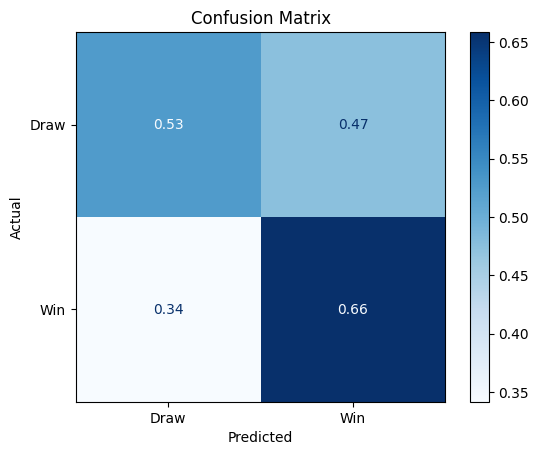

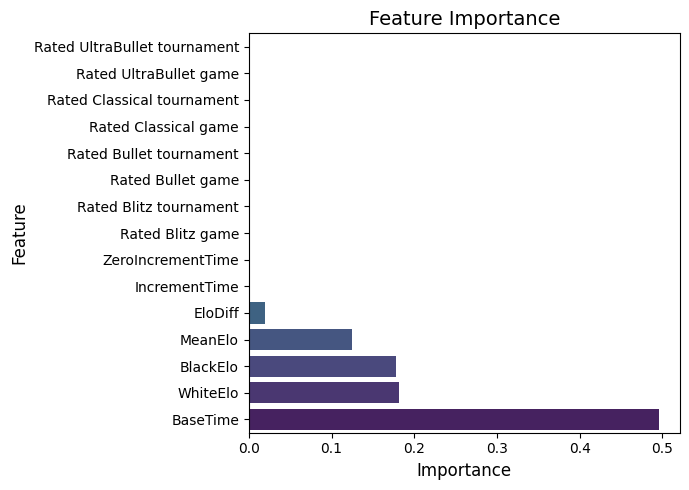

     Black to White Splitter 
DecisionTreeClassifier(class_weight='balanced', max_depth=32,
                       min_samples_leaf=5270, random_state=42)
Log Loss on test data: 0.6578
Balanced Accuracy on test data: 59.99%


                                                Classification Report
                         Valid                                      Test
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.58      0.64      0.61      4491              0.58      0.64      0.61     31936
         1-0       0.63      0.57      0.60      4790              0.62      0.56      0.59     33134
    accuracy                           0.61      9281                                  0.60     65070
   macro avg       0.61      0.61      0.61      9281              0.60      0.60      0.60     65070
weighted avg       0.61      0.61      0.61      9281              0.60      0.60      0.60     65070
       


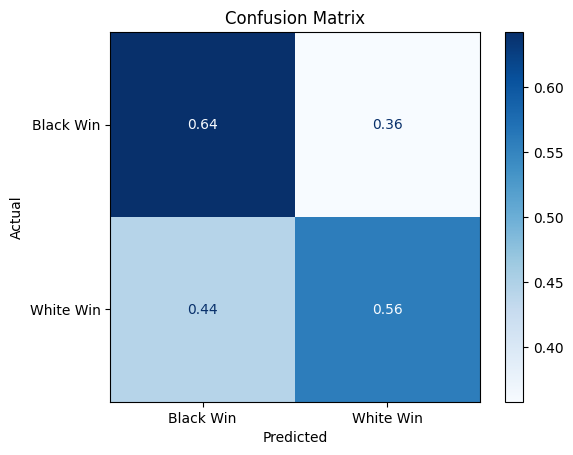

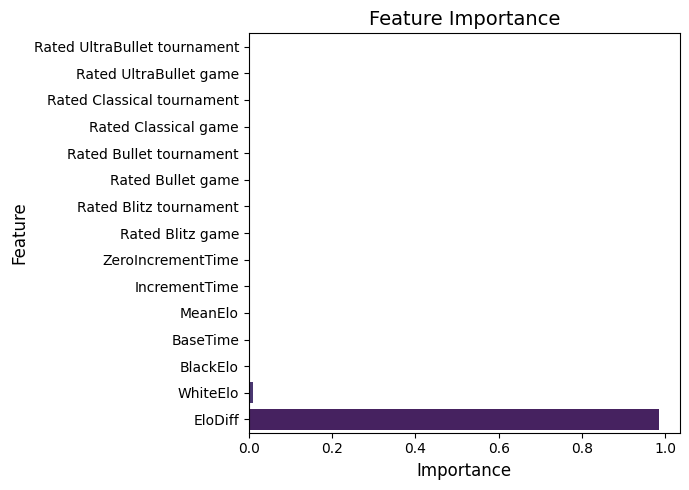

     Overall:
Log Loss on test data: 1.1315
Balanced Accuracy on test data: 43.94%


                                                Classification Report
                         Valid                                      Test
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.58      0.43      0.49      4491              0.57      0.43      0.49     31936
         1-0       0.62      0.39      0.48      4790              0.61      0.37      0.46     33134
     1/2-1/2       0.05      0.60      0.09       245              0.04      0.53      0.07      1615
    accuracy                           0.41      9526                                  0.40     66685
   macro avg       0.41      0.47      0.35      9526              0.41      0.44      0.34     66685
weighted avg       0.58      0.41      0.47      9526              0.58      0.40      0.46     66685
       


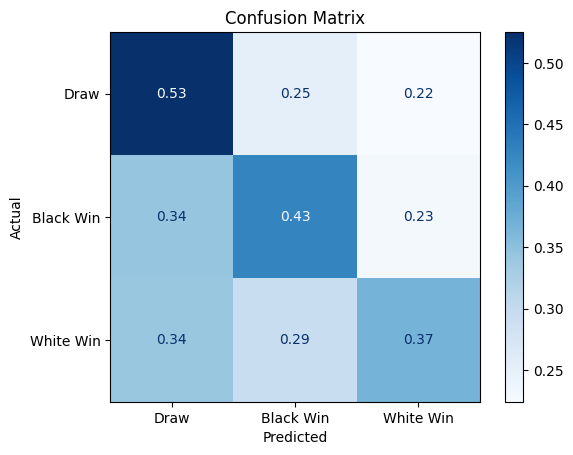

In [22]:
best_model.estimate_model(X_valid, y_valid, X_test, y_test, report_title_1="Valid", report_title_2="Test")